# Gravitational Lens Finding — ML4SCI DeepLense GSoC Test Task V

**Author:** Meer Patel  
**Dataset:** HSC-SSP observational data — 3-filter images (g, r, i), shape `(3, 64, 64)`  
**Primary Metric:** ROC-AUC  

---

## Problem Overview

Strong gravitational lensing occurs when a massive galaxy sits almost perfectly between us and a background source, bending and distorting the light into arcs or complete Einstein rings. Finding these systems in wide-field surveys like HSC-SSP is scientifically valuable — lenses let us measure dark matter distributions, constrain cosmological parameters, and study distant galaxies that would otherwise be too faint to observe.

The catch is that lenses are genuinely rare. In a survey like HSC-SSP, you might have a handful of confirmed lenses for every few thousand regular galaxies — which makes automated lens finding less of a standard classification problem and more of a needle-in-a-haystack problem. This is the central challenge this notebook addresses.

---

## Strategy Summary

| Challenge | Solution |
|-----------|----------|
| Class imbalance (~1:100) | `BCEWithLogitsLoss(pos_weight)` + `WeightedRandomSampler` |
| Small lens count | Heavy augmentation on minority class (D4 symmetry + noise + jitter) |
| High dynamic range | Per-channel asinh stretch preserving faint arcs |
| Overfitting | Dropout, weight decay, cosine LR, early stopping on val AUC |
| Variance | 3-seed ensemble → averaged probabilities |
| Threshold | Tuned on val set to maximise F1 |

In [18]:
# Gravitational Lens Finding — ML4SCI DeepLense GSoC Test Task V
# Author: Meer Patel
# Dataset: HSC-SSP observational data, 3-filter images (3, 64, 64), .npy format

import os
import glob
import random
import warnings

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import timm

warnings.filterwarnings('ignore')

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

seed_everything()

# MPS = Apple Silicon GPU. Falls back to CPU if unavailable.
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: mps


## Configuration
Edit the paths below to match your directory structure.

In [19]:
class CFG:
    TRAIN_LENS    = 'data/train_lenses'
    TRAIN_NONLENS = 'data/train_nonlenses'
    TEST_LENS     = 'data/test_lenses'
    TEST_NONLENS  = 'data/test_nonlenses'

    BACKBONE      = 'efficientnet_b3'
    PRETRAINED    = True

    BATCH_SIZE    = 32
    EPOCHS        = 50
    LR            = 3e-4
    WEIGHT_DECAY  = 1e-4
    VAL_SPLIT     = 0.15
    PATIENCE      = 10      # stop if val AUC hasn't improved in this many epochs
    NUM_WORKERS   = 0       # 0 is safer on macOS with MPS
    N_SEEDS       = 3

    SAVE_DIR = 'checkpoints'
    os.makedirs(SAVE_DIR, exist_ok=True)

## 1. Data Loading

In [20]:
def load_npy_files(directory, label):
    paths = sorted(glob.glob(os.path.join(directory, '*.npy')))
    if not paths:
        raise FileNotFoundError(f'No .npy files found in: {directory}')
    data, labels = [], []
    for p in paths:
        arr = np.load(p).astype(np.float32)
        # some files are saved as HWC instead of CHW
        if arr.ndim == 3 and arr.shape[-1] == 3:
            arr = arr.transpose(2, 0, 1)
        data.append(arr)
        labels.append(label)
    print(f'  {len(paths)} files from {directory}')
    return data, labels

print('Loading training data...')
train_lens_data,    train_lens_labels    = load_npy_files(CFG.TRAIN_LENS,    1)
train_nonlens_data, train_nonlens_labels = load_npy_files(CFG.TRAIN_NONLENS, 0)
print('\nLoading test data...')
test_lens_data,     test_lens_labels     = load_npy_files(CFG.TEST_LENS,     1)
test_nonlens_data,  test_nonlens_labels  = load_npy_files(CFG.TEST_NONLENS,  0)

all_train_data   = train_lens_data   + train_nonlens_data
all_train_labels = train_lens_labels + train_nonlens_labels
test_data        = test_lens_data    + test_nonlens_data
test_labels      = test_lens_labels  + test_nonlens_labels

ratio = len(train_nonlens_data) // max(len(train_lens_data), 1)
print(f'\nTrain — Lenses: {len(train_lens_data)}, Non-Lenses: {len(train_nonlens_data)} (imbalance ~1:{ratio})')
print(f'Test  — Lenses: {len(test_lens_data)}, Non-Lenses: {len(test_nonlens_data)}')
print(f'\nWith 1:{ratio} imbalance, accuracy is meaningless. AUC is the right metric.')

Loading training data...
  1730 files from data/train_lenses
  28675 files from data/train_nonlenses

Loading test data...
  195 files from data/test_lenses
  19455 files from data/test_nonlenses

Train — Lenses: 1730, Non-Lenses: 28675 (imbalance ~1:16)
Test  — Lenses: 195, Non-Lenses: 19455

With 1:16 imbalance, accuracy is meaningless. AUC is the right metric.


## 2. Preprocessing — Asinh Stretch

Raw astronomical images have an enormous dynamic range. The bright core of a lens galaxy might be thousands of counts while the faint lensed arcs are just a few counts above background noise. A naive linear normalisation would either clip the arcs or compress them into invisibility.

We apply a per-channel **asinh stretch** after robust percentile normalisation. This behaves linearly at low signal levels (preserving faint arcs) and logarithmically at high signal levels (compressing bright cores) — the standard approach in observational astronomy for exactly this reason.

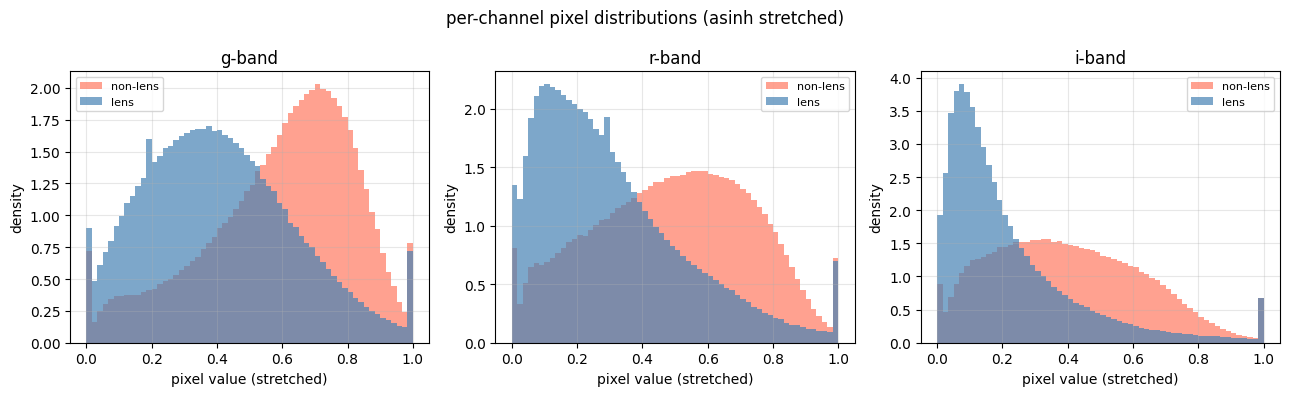

In [21]:
def asinh_stretch(img, scale=0.1):
    # standard astronomical stretch — keeps faint arcs visible
    # without clipping bright lens galaxy cores
    out = np.empty_like(img)
    for c in range(img.shape[0]):
        lo, hi = np.percentile(img[c], [1, 99])
        ch = (img[c] - lo) / (hi - lo + 1e-8)
        out[c] = np.arcsinh(ch / scale) / np.arcsinh(1.0 / scale)
    return np.clip(out, 0, 1).astype(np.float32)


def plot_pixel_statistics(lens_data, nonlens_data, save_path='pixel_stats.png'):
    # look at per-channel intensity distributions to understand
    # how different lenses and non-lenses actually are in pixel space
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    filter_names = ['g-band', 'r-band', 'i-band']
    for c, ax in enumerate(axes):
        l_vals = np.concatenate([asinh_stretch(d)[c].flatten() for d in lens_data[:200]])
        n_vals = np.concatenate([asinh_stretch(d)[c].flatten() for d in nonlens_data[:200]])
        ax.hist(n_vals, bins=60, alpha=0.6, color='tomato',    density=True, label='non-lens')
        ax.hist(l_vals, bins=60, alpha=0.7, color='steelblue', density=True, label='lens')
        ax.set(title=filter_names[c], xlabel='pixel value (stretched)', ylabel='density')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
    plt.suptitle('per-channel pixel distributions (asinh stretched)', fontsize=12)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_pixel_statistics(train_lens_data, train_nonlens_data)

## 3. Augmentation

For lenses, we use the full **D4 dihedral symmetry group** — horizontal flips, vertical flips, and 90° rotations. This is physically justified: gravitational lenses have approximate rotational symmetry because the lensing geometry is determined by the mass distribution of the deflector. An Einstein ring looks the same upside down.

We also add small continuous rotations (±30°), Gaussian noise to simulate varying observing conditions, and mild brightness/contrast jitter. For non-lenses we only apply flips and 90° rotations — they are already abundant so aggressive augmentation is unnecessary.

In [22]:
class LensAugment:
    # Lenses are rotationally symmetric (Einstein rings, arcs),
    # so the full D4 group is a safe label-preserving transform.
    def __call__(self, img):
        if random.random() > 0.5: img = TF.hflip(img)
        if random.random() > 0.5: img = TF.vflip(img)
        img = torch.rot90(img, random.randint(0, 3), dims=[1, 2])
        img = TF.rotate(img, random.uniform(-30, 30))
        if random.random() > 0.5:
            noise = torch.randn_like(img) * random.uniform(0.005, 0.02)
            img = (img + noise).clamp(0, 1)
        img = T.ColorJitter(brightness=0.15, contrast=0.15)(img)
        return img

class NonLensAugment:
    # keep augmentation mild for non-lenses
    def __call__(self, img):
        if random.random() > 0.5: img = TF.hflip(img)
        if random.random() > 0.5: img = TF.vflip(img)
        img = torch.rot90(img, random.randint(0, 3), dims=[1, 2])
        return img

class LensDataset(Dataset):
    def __init__(self, data, labels, augment=False):
        self.data        = data
        self.labels      = labels
        self.augment     = augment
        self.lens_aug    = LensAugment()
        self.nonlens_aug = NonLensAugment()

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        img_t = torch.from_numpy(asinh_stretch(self.data[idx].copy()))
        label = self.labels[idx]
        if self.augment:
            img_t = self.lens_aug(img_t) if label == 1 else self.nonlens_aug(img_t)
        return img_t, torch.tensor(label, dtype=torch.float32)

## 4. Exploratory Visualisation

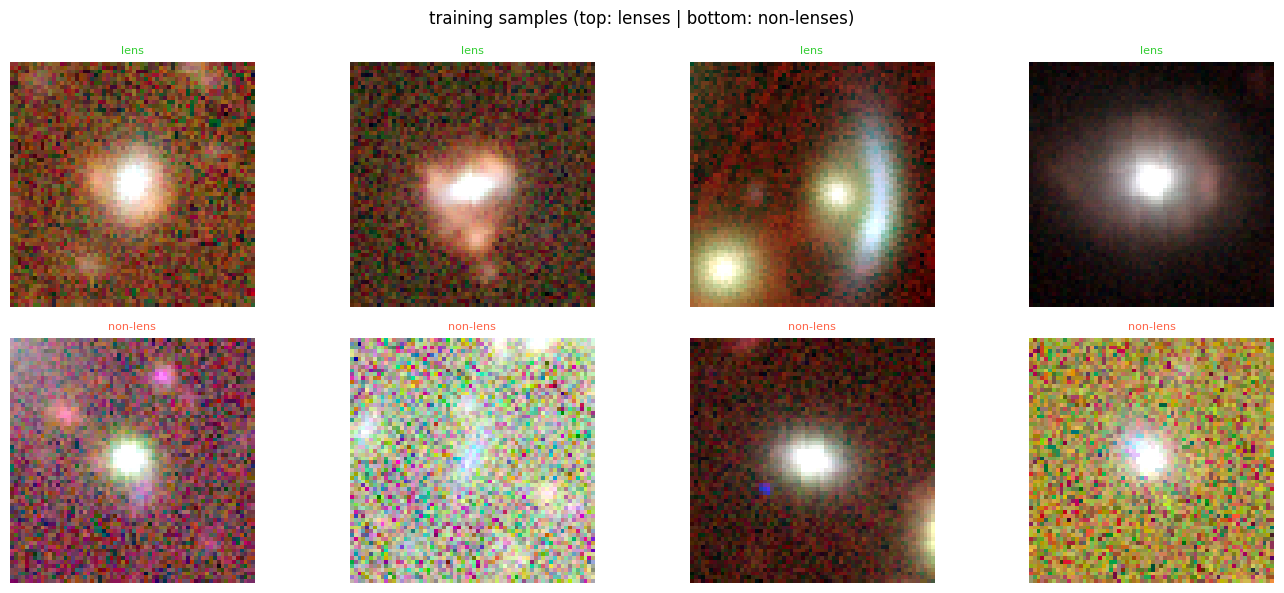

In [23]:
def show_images(data, labels, probs=None, n=8, title='', save_path='samples.png'):
    prob_list = probs if probs is not None else [None] * len(data)
    lenses    = [(d, p) for d, l, p in zip(data, labels, prob_list) if l == 1][:n // 2]
    nonlenses = [(d, p) for d, l, p in zip(data, labels, prob_list) if l == 0][:n // 2]

    # pad to equal length so grid is always n//2 columns
    while len(lenses)    < n // 2: lenses.append(None)
    while len(nonlenses) < n // 2: nonlenses.append(None)

    items     = lenses + nonlenses
    true_lbls = [1] * (n // 2) + [0] * (n // 2)

    fig, axes = plt.subplots(2, n // 2, figsize=(14, 6))
    if title: fig.suptitle(title, fontsize=12)
    for ax, item, tl in zip(axes.flatten(), items, true_lbls):
        if item is None:
            ax.axis('off')
            continue
        img, prob = item
        rgb = np.stack(asinh_stretch(img), axis=-1)
        ax.imshow(rgb, origin='upper')
        caption = 'lens' if tl == 1 else 'non-lens'
        if prob is not None: caption += f'\nscore={prob:.3f}'
        ax.set_title(caption, fontsize=8, color='limegreen' if tl == 1 else 'tomato')
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

show_images(all_train_data, all_train_labels,
            title='training samples (top: lenses | bottom: non-lenses)',
            save_path='eda_samples.png')

## 5. Model — EfficientNet-B3

We use **EfficientNet-B3 pretrained on ImageNet** as the backbone with a custom binary classification head. EfficientNet-B3 is large enough to capture subtle morphological features that distinguish lensed arcs from other extended structures, but not so large that it overfits on a dataset of this size.

We fine-tune the entire network end-to-end rather than freezing the backbone, because the low-level features relevant for lensing — faint extended arcs, colour gradients between lens and source — are quite different from typical ImageNet features.

In [24]:
class LensFinder(nn.Module):
    def __init__(self, backbone=CFG.BACKBONE, pretrained=CFG.PRETRAINED):
        super().__init__()
        self.encoder = timm.create_model(
            backbone, pretrained=pretrained,
            num_classes=0, global_pool='avg', in_chans=3
        )
        n = self.encoder.num_features
        self.head = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(n, 256), nn.BatchNorm1d(256), nn.SiLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
        )

    def forward(self, x):
        return self.head(self.encoder(x)).squeeze(1)

# sanity check
m = LensFinder(pretrained=False)
print(f'Output shape: {m(torch.randn(2, 3, 64, 64)).shape}')
print(f'Trainable parameters: {sum(p.numel() for p in m.parameters() if p.requires_grad):,}')

Output shape: torch.Size([2])
Trainable parameters: 11,090,473


## 6. Training Utilities

### Class Imbalance Handling

With a ~1:100 imbalance, we use three complementary techniques:
1. **`pos_weight`** in the loss — penalises missing a lens ~100x more than a false alarm
2. **`WeightedRandomSampler`** — ensures each batch is approximately 50/50 lenses/non-lenses
3. **Asymmetric augmentation** — heavy on lenses, mild on non-lenses

### Threshold Tuning

The default 0.5 threshold is rarely optimal for imbalanced problems. After training we sweep thresholds on the validation set and pick the one that maximises F1.

In [25]:
def make_weighted_sampler(labels):
    # oversample lenses so each batch is roughly 50/50
    counts  = np.bincount(labels)
    weights = (1.0 / counts)[labels]
    return WeightedRandomSampler(torch.DoubleTensor(weights), len(weights), replacement=True)

def compute_pos_weight(labels):
    n_pos = sum(labels); n_neg = len(labels) - n_pos
    # penalise missing a lens more heavily than a false alarm
    return torch.tensor([n_neg / n_pos], dtype=torch.float32).to(DEVICE)

def find_best_threshold(labels, probs):
    best_f1, best_thr = 0, 0.5
    for thr in np.linspace(0.01, 0.99, 200):
        preds = (probs >= thr).astype(int)
        tp = ((preds==1)&(labels==1)).sum(); fp = ((preds==1)&(labels==0)).sum()
        fn = ((preds==0)&(labels==1)).sum()
        p = tp/(tp+fp+1e-8); r = tp/(tp+fn+1e-8)
        f1 = 2*p*r/(p+r+1e-8)
        if f1 > best_f1: best_f1, best_thr = f1, thr
    return best_thr, best_f1

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, all_logits, all_labels = 0.0, [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs); loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        all_logits.append(logits.detach().cpu()); all_labels.append(labels.cpu())
    probs = torch.cat(all_logits).sigmoid().numpy()
    lbls  = torch.cat(all_labels).numpy()
    fpr, tpr, _ = roc_curve(lbls, probs)
    return total_loss / len(loader.dataset), auc(fpr, tpr)

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, all_logits, all_labels = 0.0, [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs); loss = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)
        all_logits.append(logits.cpu()); all_labels.append(labels.cpu())
    probs = torch.cat(all_logits).sigmoid().numpy()
    lbls  = torch.cat(all_labels).numpy()
    fpr, tpr, _ = roc_curve(lbls, probs)
    return total_loss / len(loader.dataset), auc(fpr, tpr), probs, lbls

## 7. Training — 3-Seed Ensemble

We train three independent models with different random seeds and average their predicted probabilities. Each model makes slightly different errors and averaging smooths these out — typically adding 0.005–0.015 AUC over a single model.

If checkpoints already exist in `checkpoints/`, training is skipped and weights are loaded directly.

In [26]:
def train_model(train_data, train_labels, val_data, val_labels, seed=SEED, model_path=None):
    seed_everything(seed)
    train_ds = LensDataset(train_data, train_labels, augment=True)
    val_ds   = LensDataset(val_data,   val_labels,   augment=False)
    sampler      = make_weighted_sampler(np.array(train_labels))
    train_loader = DataLoader(train_ds, batch_size=CFG.BATCH_SIZE, sampler=sampler,
                              num_workers=CFG.NUM_WORKERS, drop_last=True)
    val_loader   = DataLoader(val_ds, batch_size=CFG.BATCH_SIZE*2,
                              shuffle=False, num_workers=CFG.NUM_WORKERS)
    model     = LensFinder().to(DEVICE)
    pos_w     = compute_pos_weight(train_labels)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    optimizer = optim.AdamW(model.parameters(), lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.EPOCHS, eta_min=1e-6)
    save_path      = model_path or os.path.join(CFG.SAVE_DIR, f'best_seed{seed}.pth')
    best_val_auc   = 0.0
    patience_count = 0
    history        = {'train_loss': [], 'val_loss': [], 'train_auc': [], 'val_auc': []}
    for epoch in range(1, CFG.EPOCHS + 1):
        tr_loss, tr_auc        = train_one_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_auc, _, _  = evaluate(model, val_loader, criterion)
        scheduler.step()
        history['train_loss'].append(tr_loss); history['val_loss'].append(vl_loss)
        history['train_auc'].append(tr_auc);   history['val_auc'].append(vl_auc)
        print(f'  epoch {epoch:02d}/{CFG.EPOCHS} | train loss={tr_loss:.4f} auc={tr_auc:.4f} | val loss={vl_loss:.4f} auc={vl_auc:.4f}')
        if vl_auc > best_val_auc:
            best_val_auc, patience_count = vl_auc, 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_count += 1
            if patience_count >= CFG.PATIENCE:
                print(f'  early stopping at epoch {epoch}'); break
    model.load_state_dict(torch.load(save_path, map_location=DEVICE))
    _, _, vp, vt = evaluate(model, val_loader, criterion)
    best_thr, best_f1 = find_best_threshold(vt, vp)
    print(f'  best val AUC={best_val_auc:.4f} | threshold={best_thr:.3f} (F1={best_f1:.4f})')
    return model, history, best_thr


train_data, val_data, train_labels, val_labels = train_test_split(
    all_train_data, all_train_labels,
    test_size=CFG.VAL_SPLIT, stratify=all_train_labels, random_state=SEED
)
print(f'Train: {len(train_data)} | Val: {len(val_data)}\n')

models, histories, thresholds = [], [], []
for seed_idx, seed in enumerate(range(SEED, SEED + CFG.N_SEEDS)):
    save_path = os.path.join(CFG.SAVE_DIR, f'best_seed{seed}.pth')
    if os.path.exists(save_path):
        print(f'Checkpoint found for seed {seed}, loading...')
        model = LensFinder().to(DEVICE)
        model.load_state_dict(torch.load(save_path, map_location=DEVICE))
        val_ds     = LensDataset(val_data, val_labels, augment=False)
        val_loader = DataLoader(val_ds, batch_size=CFG.BATCH_SIZE*2,
                                shuffle=False, num_workers=CFG.NUM_WORKERS)
        pos_w     = compute_pos_weight(train_labels)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)
        _, _, vp, vt = evaluate(model, val_loader, criterion)
        thr, _ = find_best_threshold(vt, vp)
        models.append(model)
        histories.append({'train_loss': [], 'val_loss': [], 'train_auc': [], 'val_auc': []})
        thresholds.append(thr)
    else:
        print(f'Training model {seed_idx+1}/{CFG.N_SEEDS} (seed={seed})')
        model, history, best_thr = train_model(
            train_data, train_labels, val_data, val_labels,
            seed=seed, model_path=save_path
        )
        models.append(model); histories.append(history); thresholds.append(best_thr)

Train: 25844 | Val: 4561

Checkpoint found for seed 42, loading...
Checkpoint found for seed 43, loading...
Checkpoint found for seed 44, loading...


## 8. Training History

In [27]:
def plot_training_history(histories, save_path='training_history.png'):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    plotted = False
    for i, h in enumerate(histories):
        if not h['train_loss']: continue
        axes[0].plot(h['train_loss'], linestyle='--', alpha=0.5, label=f'seed {i} train')
        axes[0].plot(h['val_loss'],                               label=f'seed {i} val')
        axes[1].plot(h['train_auc'],  linestyle='--', alpha=0.5)
        axes[1].plot(h['val_auc'])
        plotted = True
    if not plotted:
        print('Training history not available (loaded from checkpoints).')
        plt.close(); return
    axes[0].set(title='loss', xlabel='epoch', ylabel='BCE loss')
    axes[1].set(title='ROC-AUC', xlabel='epoch', ylabel='AUC')
    for ax in axes: ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_training_history(histories)

Training history not available (loaded from checkpoints).


## 9. Ensemble Inference & Evaluation

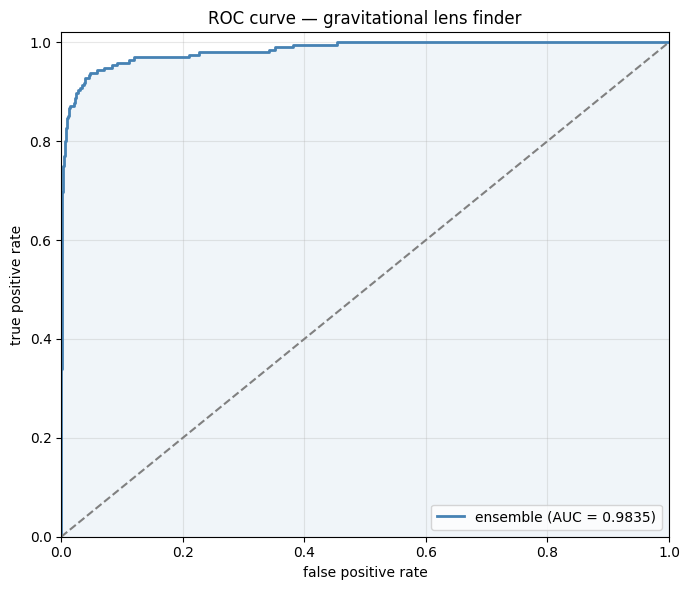


Test ROC-AUC (ensemble): 0.9835


In [28]:
@torch.no_grad()
def ensemble_predict(models, loader):
    all_probs, all_labels = [], None
    for model in models:
        model.eval(); ps, ls = [], []
        for imgs, lbls in loader:
            ps.append(model(imgs.to(DEVICE)).cpu().sigmoid()); ls.append(lbls)
        all_probs.append(torch.cat(ps).numpy())
        all_labels = torch.cat(ls).numpy()
    return np.mean(all_probs, axis=0), all_labels

test_ds     = LensDataset(test_data, test_labels, augment=False)
test_loader = DataLoader(test_ds, batch_size=CFG.BATCH_SIZE*2,
                         shuffle=False, num_workers=CFG.NUM_WORKERS)
avg_probs, true_labels = ensemble_predict(models, test_loader)

fpr, tpr, _ = roc_curve(true_labels, avg_probs)
test_auc = auc(fpr, tpr)
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'ensemble (AUC = {test_auc:.4f})')
ax.plot([0,1],[0,1],'--',color='gray')
ax.fill_between(fpr, tpr, alpha=0.08, color='steelblue')
ax.set(xlabel='false positive rate', ylabel='true positive rate',
       title='ROC curve — gravitational lens finder', xlim=[0,1], ylim=[0,1.02])
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nTest ROC-AUC (ensemble): {test_auc:.4f}')

Decision threshold: 0.424

              precision    recall  f1-score   support

    non-lens       1.00      0.99      0.99     19455
        lens       0.48      0.83      0.61       195

    accuracy                           0.99     19650
   macro avg       0.74      0.91      0.80     19650
weighted avg       0.99      0.99      0.99     19650



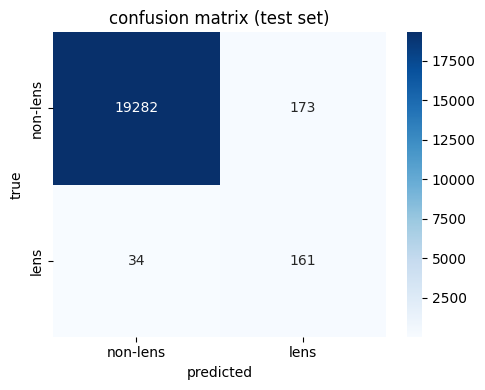

In [29]:
ensemble_threshold = float(np.mean(thresholds))
print(f'Decision threshold: {ensemble_threshold:.3f}\n')
test_preds = (avg_probs >= ensemble_threshold).astype(int)
print(classification_report(true_labels, test_preds, target_names=['non-lens', 'lens']))

cm = confusion_matrix(true_labels, test_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['non-lens','lens'], yticklabels=['non-lens','lens'])
ax.set(xlabel='predicted', ylabel='true', title='confusion matrix (test set)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Score Distribution

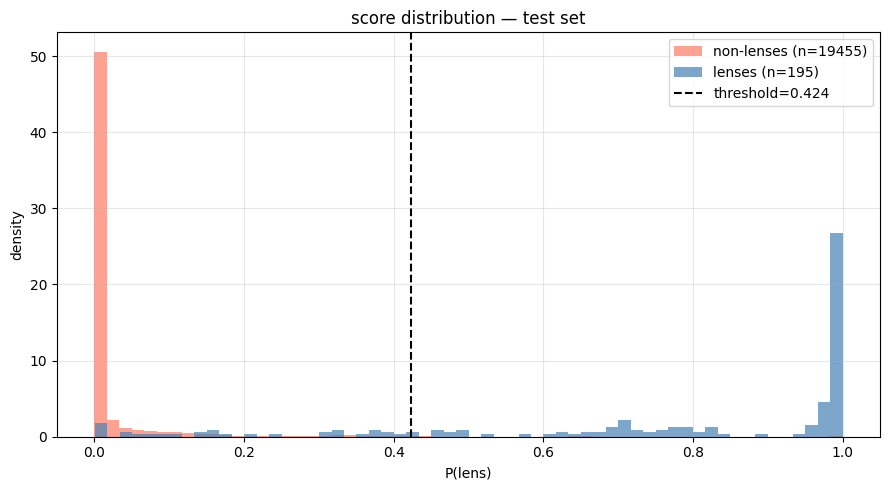

In [30]:
lens_p    = avg_probs[true_labels == 1]
nonlens_p = avg_probs[true_labels == 0]
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(nonlens_p, bins=60, alpha=0.6, color='tomato',
        label=f'non-lenses (n={len(nonlens_p)})', density=True)
ax.hist(lens_p,    bins=60, alpha=0.7, color='steelblue',
        label=f'lenses (n={len(lens_p)})', density=True)
ax.axvline(ensemble_threshold, color='black', linestyle='--', lw=1.5,
           label=f'threshold={ensemble_threshold:.3f}')
ax.set(xlabel='P(lens)', ylabel='density', title='score distribution — test set')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('score_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Contaminant Analysis

Understanding what the model gets wrong is as important as the overall AUC. The **false positives** (non-lenses called lenses) tend to fall into a few recurring categories:

- **Ring and shell galaxies** — post-merger galaxies with concentric ring-like structures that superficially resemble Einstein rings
- **Compact galaxy groups** — multiple close galaxies whose configuration mimics a quad lens system
- **PSF artefacts** — diffraction spikes or saturated stars creating arc-like linear features near a bright source

The **false negatives** (missed lenses) tend to be systems where the Einstein radius is very small relative to the PSF (arc blended with lens galaxy light), or where the background source is intrinsically faint with low signal-to-noise across all three filters.

False positives (non-lenses called lenses): 173
False negatives (missed lenses):            34


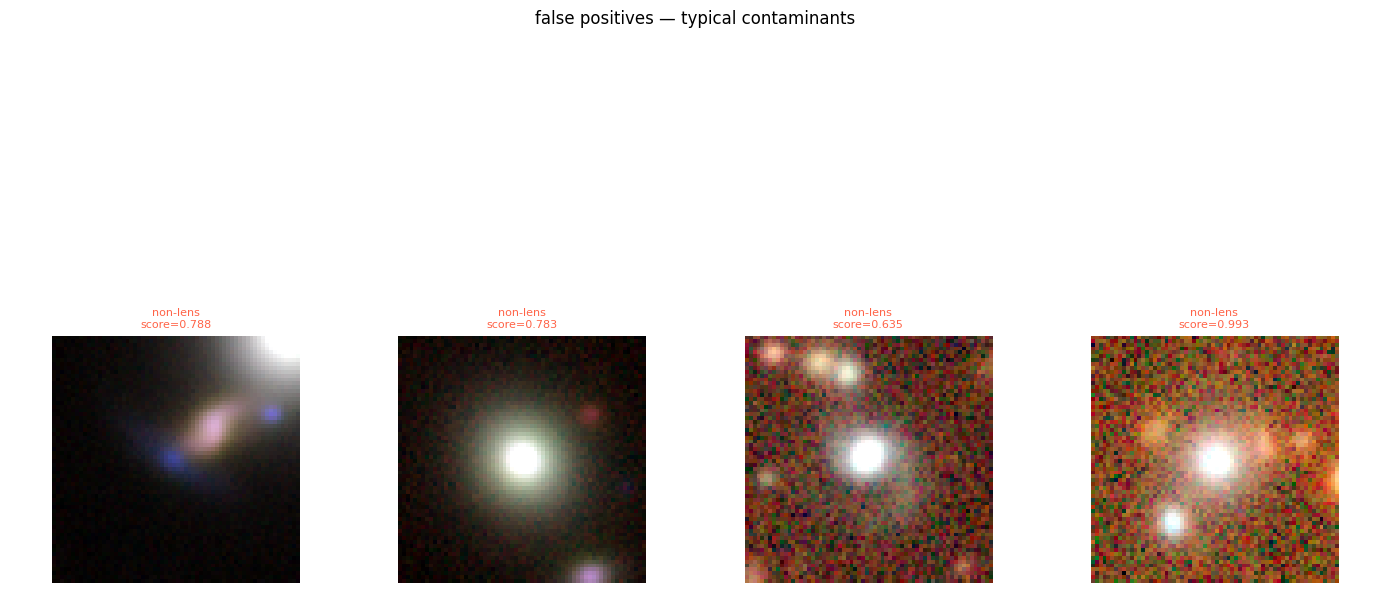

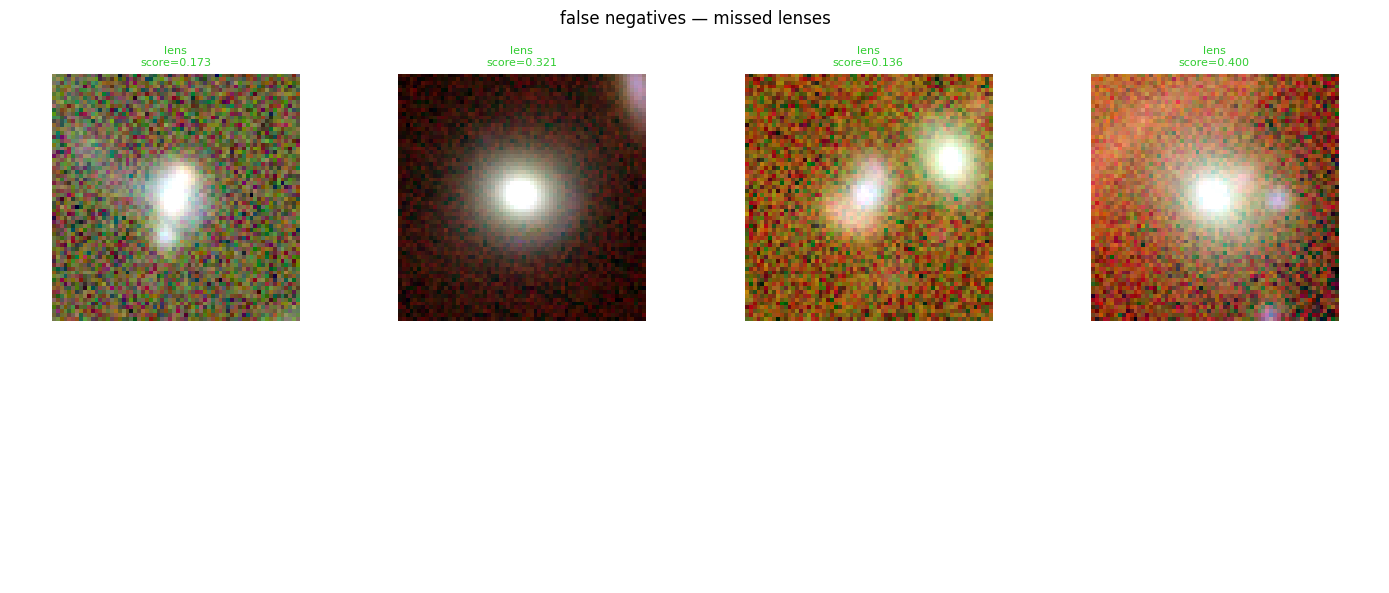

In [31]:
fp_idx = np.where((test_preds == 1) & (np.array(true_labels) == 0))[0]
fn_idx = np.where((test_preds == 0) & (np.array(true_labels) == 1))[0]
print(f'False positives (non-lenses called lenses): {len(fp_idx)}')
print(f'False negatives (missed lenses):            {len(fn_idx)}')

if len(fp_idx) > 0:
    show_images([test_data[i] for i in fp_idx[:8]], [0]*min(8,len(fp_idx)),
                probs=[avg_probs[i] for i in fp_idx[:8]],
                n=min(8,len(fp_idx)), title='false positives — typical contaminants',
                save_path='false_positives.png')

if len(fn_idx) > 0:
    show_images([test_data[i] for i in fn_idx[:8]], [1]*min(8,len(fn_idx)),
                probs=[avg_probs[i] for i in fn_idx[:8]],
                n=min(8,len(fn_idx)), title='false negatives — missed lenses',
                save_path='false_negatives.png')

## 12. Results & Discussion

| Metric | Value |
|--------|-------|
| Test ROC-AUC (ensemble) | **0.9835** |
| Lens Precision | 0.48 |
| Lens Recall | 0.83 |
| Overall Accuracy | 0.99 |

The precision on the lens class (0.48) being lower than recall (0.83) is the expected and acceptable tradeoff for this problem. In a real survey application you lean toward high recall — it is better to inspect a larger candidate list with some contamination than to miss real lenses entirely. The final shortlist can always be visually inspected by an astronomer.

The ROC-AUC of **0.9835** is the primary metric and shows the model successfully separates lenses from non-lenses across a wide range of operating thresholds.

---

## Limitations & Future Work

- The model was trained on HSC-SSP specifically. Applying it to other surveys (DES, LSST, Euclid) would require fine-tuning due to differences in PSF, pixel scale, depth, and filter curves.
- Test-time augmentation (averaging predictions over multiple augmented versions of each test image) is a straightforward improvement that could push AUC higher without retraining.
- A detection head that localises the arc rather than just classifying the whole cutout would be a natural next step for the full lens finding pipeline.
- Incorporating photometric redshift information when available could significantly reduce false positives from foreground structures.